<a href="https://colab.research.google.com/github/aishujadhav1321/employee-attrition-project/blob/main/Employee_Attrition_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
df = pd.read_csv("employee_attrition.csv")

In [4]:
print(df.head())

   Age  Gender Department            JobRole  MonthlyIncome  YearsAtCompany  \
0   25    Male      Sales    Sales Executive           3000               1   
1   32  Female         IT  Software Engineer           6500               5   
2   28    Male         HR       HR Executive           4000               2   
3   45  Female    Finance            Manager          12000              15   
4   30    Male         IT       Data Analyst           5500               4   

   JobSatisfaction  WorkLifeBalance Overtime  PerformanceRating Attrition  
0                2                2      Yes                  3       Yes  
1                4                3       No                  4        No  
2                3                2      Yes                  3       Yes  
3                4                4       No                  5        No  
4                3                3       No                  4        No  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                20 non-null     int64 
 1   Gender             20 non-null     object
 2   Department         20 non-null     object
 3   JobRole            20 non-null     object
 4   MonthlyIncome      20 non-null     int64 
 5   YearsAtCompany     20 non-null     int64 
 6   JobSatisfaction    20 non-null     int64 
 7   WorkLifeBalance    20 non-null     int64 
 8   Overtime           20 non-null     object
 9   PerformanceRating  20 non-null     int64 
 10  Attrition          20 non-null     object
dtypes: int64(6), object(5)
memory usage: 1.8+ KB
None


In [6]:
df.dropna(inplace=True)

In [7]:
print(df["Attrition"].value_counts())

Attrition
No     12
Yes     8
Name: count, dtype: int64


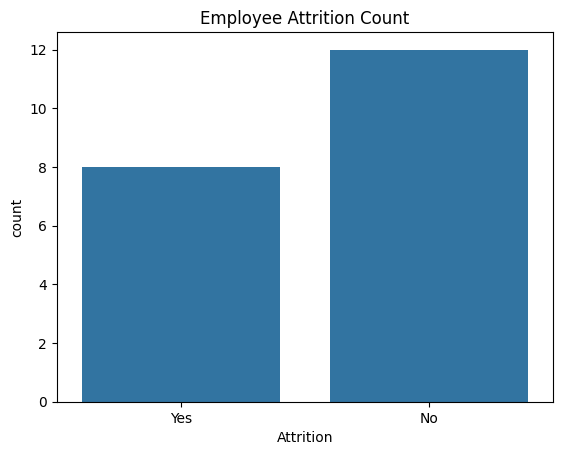

In [8]:
sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Count")
plt.show()

In [9]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

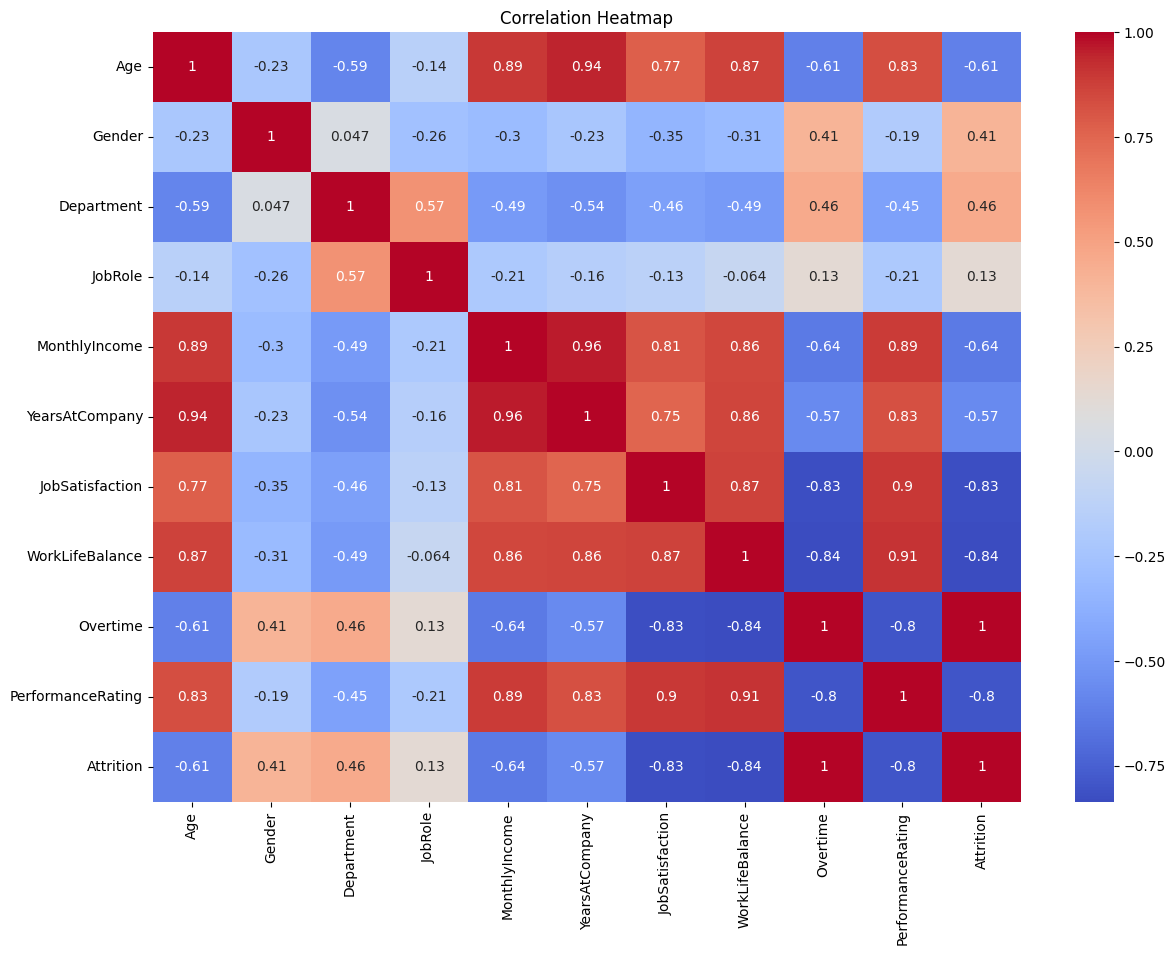

In [10]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

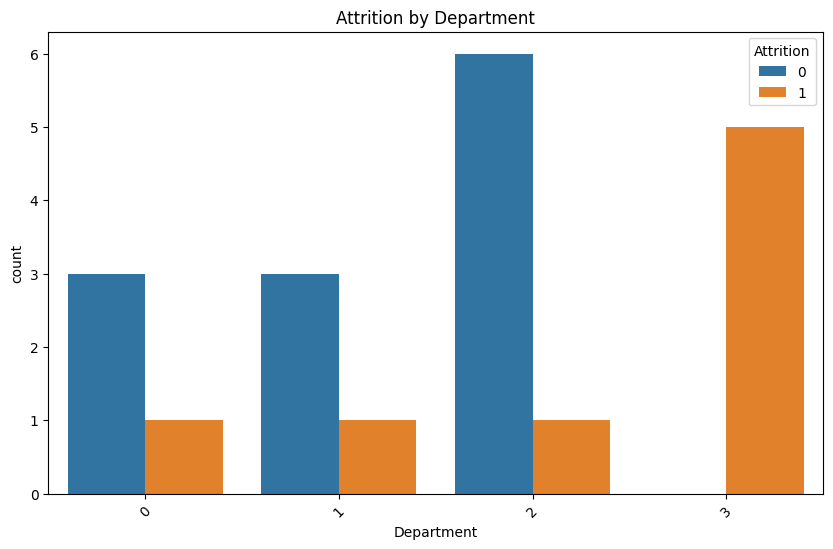

In [11]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=45)

plt.title("Attrition by Department")

plt.show()

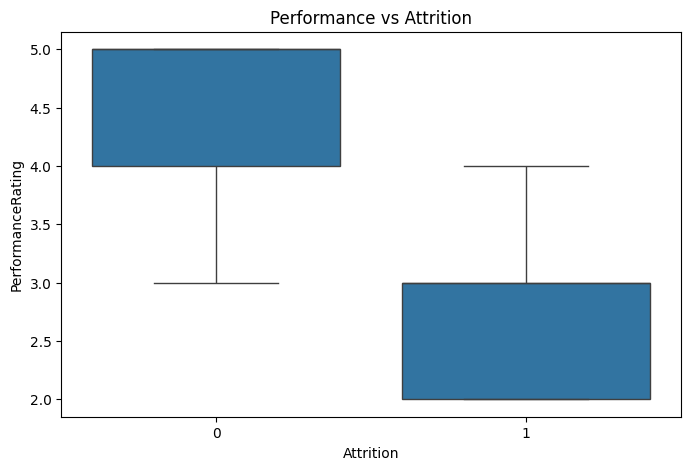

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="PerformanceRating",
    data=df
)

plt.title("Performance vs Attrition")

plt.show()

In [16]:
#Define Features & Target
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [15]:
#spilt dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
#Creates Random Forest model.
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
#Predicts attrition on test data.
y_pred = model.predict(X_test)

In [20]:
#Checks model performance accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [21]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



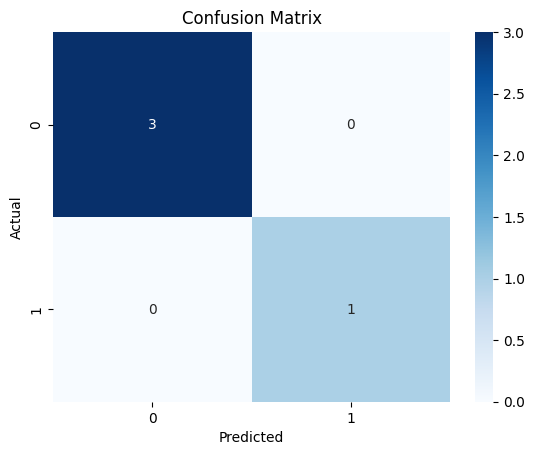

In [22]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [23]:
#Shows which features affect attrition most.
mportance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
8           Overtime    0.237714
7    WorkLifeBalance    0.221720
4      MonthlyIncome    0.118919
2         Department    0.100471
0                Age    0.094723
5     YearsAtCompany    0.083073
6    JobSatisfaction    0.074372
9  PerformanceRating    0.050244
3            JobRole    0.014943
1             Gender    0.003822


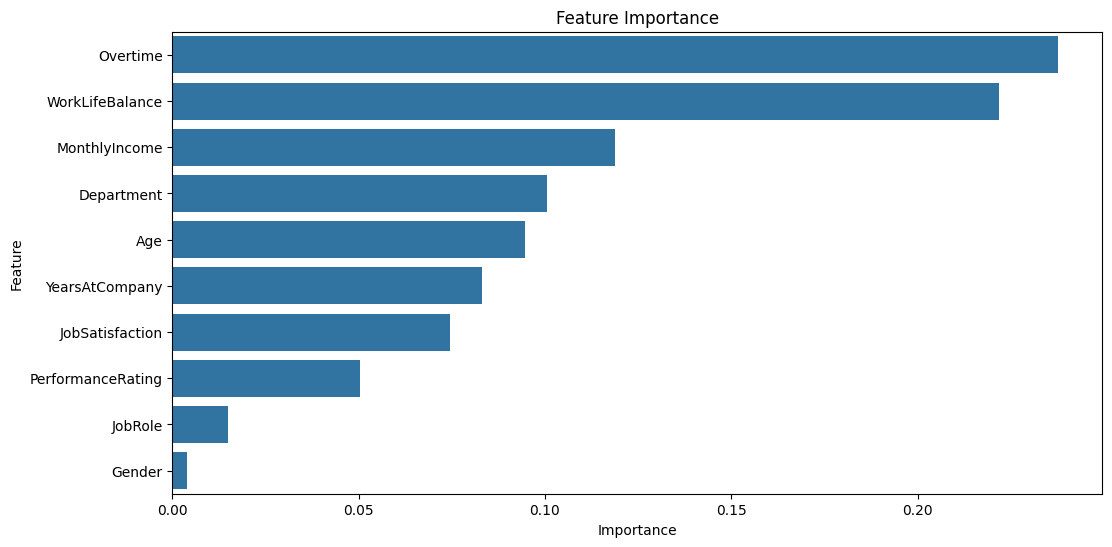

In [25]:
#Visual graph of important features.
plt.figure(figsize=(12,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [26]:
#Saves trained model file.
joblib.dump(model, "employee_attrition_model.pkl")

['employee_attrition_model.pkl']

In [27]:
#Load Model Again
loaded_model = joblib.load(
    "employee_attrition_model.pkl"
)

In [29]:
sample_employee = [[
    35,   # Age
    1,    # Gender (Assuming 1 for Male based on original sample's position)
    2,    # Department (Encoded value)
    5,    # JobRole (Hypothetical encoded value, was missing)
    5000, # MonthlyIncome
    5,    # YearsAtCompany
    3,    # JobSatisfaction
    3,    # WorkLifeBalance (Hypothetical value, was missing)
    1,    # Overtime (Encoded value)
    3     # PerformanceRating
]]

prediction = loaded_model.predict(sample_employee)

probability = loaded_model.predict_proba(sample_employee)

print("Prediction:", prediction)

print("Probability:", probability)

Prediction: [0]
Probability: [[0.55 0.45]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [30]:
risk_probability = probability[0][1]

if risk_probability > 0.70:
    print("High Risk Employee")

else:
    print("Low Risk Employee")

Low Risk Employee


FIRST 5 ROWS
   Age  Gender Department            JobRole  MonthlyIncome  YearsAtCompany  \
0   25    Male      Sales    Sales Executive           3000               1   
1   32  Female         IT  Software Engineer           6500               5   
2   28    Male         HR       HR Executive           4000               2   
3   45  Female    Finance            Manager          12000              15   
4   30    Male         IT       Data Analyst           5500               4   

   JobSatisfaction  WorkLifeBalance Overtime  PerformanceRating Attrition  
0                2                2      Yes                  3       Yes  
1                4                3       No                  4        No  
2                3                2      Yes                  3       Yes  
3                4                4       No                  5        No  
4                3                3       No                  4        No  

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
Rang

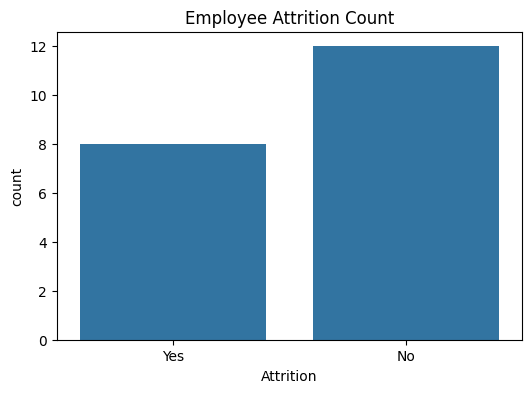


ENCODED DATA
   Age  Gender  Department  JobRole  MonthlyIncome  YearsAtCompany  \
0   25       1           3       11           3000               1   
1   32       0           2       14           6500               5   
2   28       1           1        5           4000               2   
3   45       0           0        8          12000              15   
4   30       1           2        1           5500               4   

   JobSatisfaction  WorkLifeBalance  Overtime  PerformanceRating  Attrition  
0                2                2         1                  3          1  
1                4                3         0                  4          0  
2                3                2         1                  3          1  
3                4                4         0                  5          0  
4                3                3         0                  4          0  


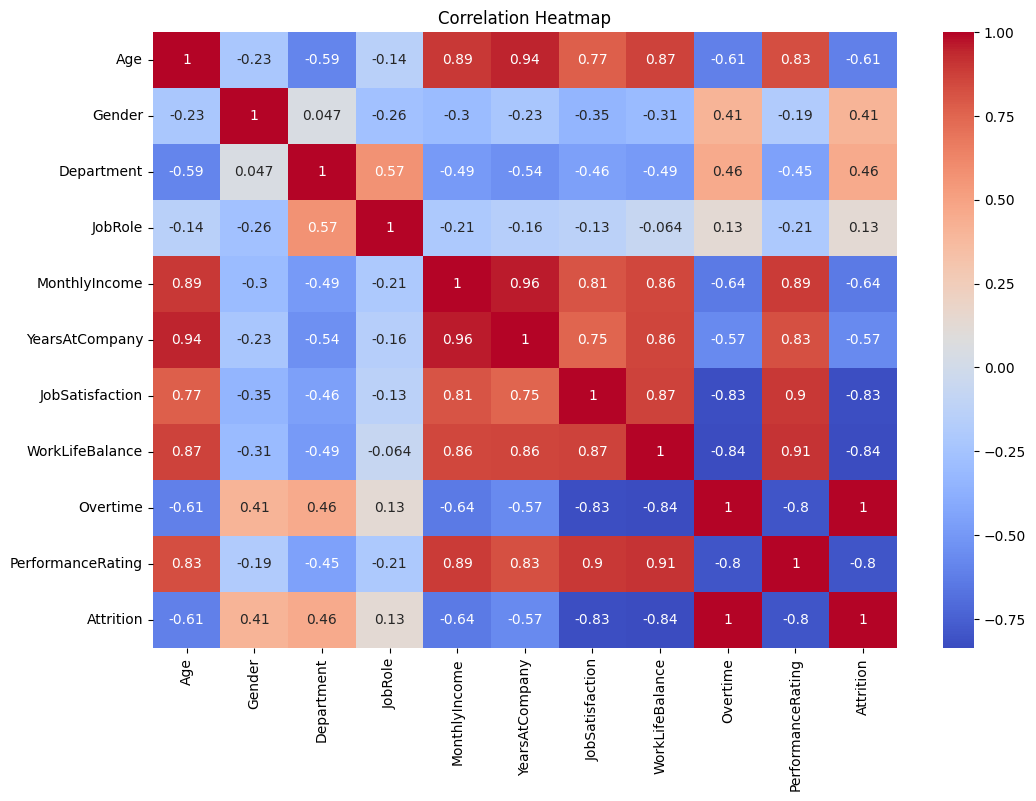

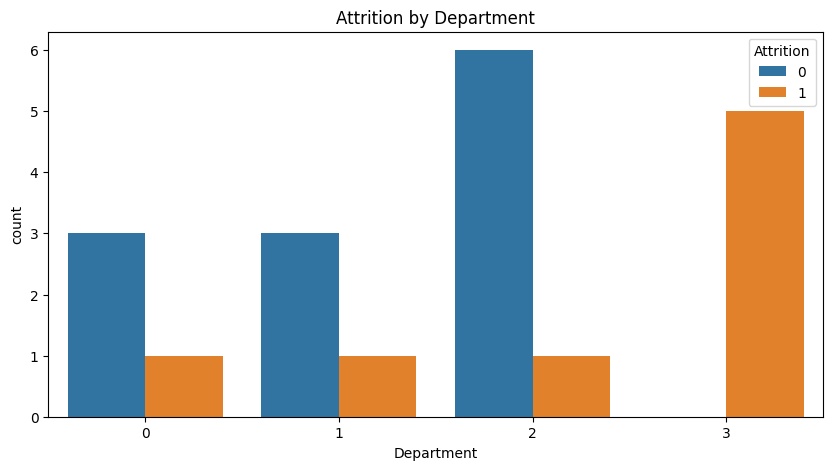

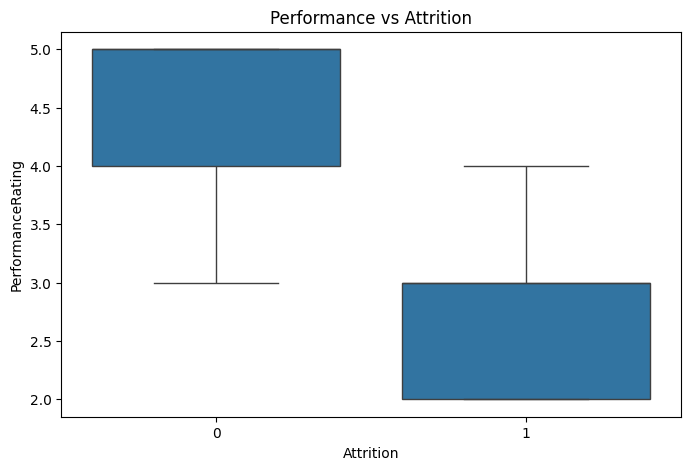


MODEL ACCURACY
Accuracy: 1.0

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



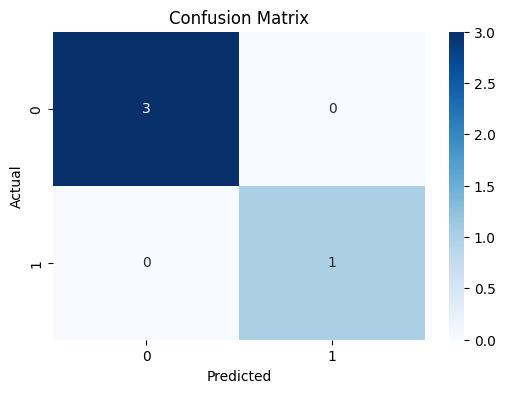


FEATURE IMPORTANCE
             Feature  Importance
8           Overtime    0.237714
7    WorkLifeBalance    0.221720
4      MonthlyIncome    0.118919
2         Department    0.100471
0                Age    0.094723
5     YearsAtCompany    0.083073
6    JobSatisfaction    0.074372
9  PerformanceRating    0.050244
3            JobRole    0.014943
1             Gender    0.003822


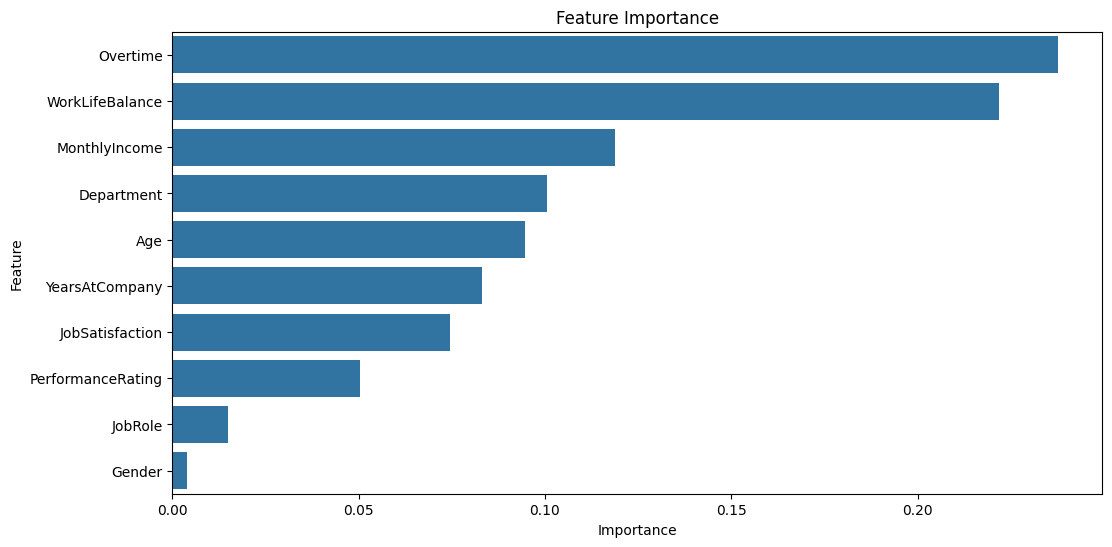


MODEL SAVED SUCCESSFULLY

PREDICTION RESULT
Employee may leave company

Attrition Probability: 0.73
HIGH RISK EMPLOYEE


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [31]:
# ================================
# EMPLOYEE ATTRITION ANALYTICS PROJECT
# COMPLETE CODE IN ONE CELL
# ================================

# STEP 1 - IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

# ================================
# STEP 2 - LOAD DATASET
# ================================

df = pd.read_csv("employee_attrition.csv")

# ================================
# STEP 3 - SHOW DATA
# ================================

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET INFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

# ================================
# STEP 4 - REMOVE NULL VALUES
# ================================

df.dropna(inplace=True)

# ================================
# STEP 5 - ATTRITION COUNT
# ================================

print("\nATTRITION COUNT")
print(df["Attrition"].value_counts())

# ================================
# STEP 6 - VISUALIZE ATTRITION
# ================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="Attrition",
    data=df
)

plt.title("Employee Attrition Count")

plt.show()

# ================================
# STEP 7 - ENCODE CATEGORICAL DATA
# ================================

le = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

print("\nENCODED DATA")
print(df.head())

# ================================
# STEP 8 - CORRELATION HEATMAP
# ================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ================================
# STEP 9 - ATTRITION BY DEPARTMENT
# ================================

plt.figure(figsize=(10,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.title("Attrition by Department")

plt.show()

# ================================
# STEP 10 - PERFORMANCE VS ATTRITION
# ================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="PerformanceRating",
    data=df
)

plt.title("Performance vs Attrition")

plt.show()

# ================================
# STEP 11 - DEFINE FEATURES & TARGET
# ================================

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

# ================================
# STEP 12 - SPLIT DATA
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ================================
# STEP 13 - TRAIN MODEL
# ================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ================================
# STEP 14 - PREDICTION
# ================================

y_pred = model.predict(X_test)

# ================================
# STEP 15 - ACCURACY
# ================================

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY")
print("Accuracy:", accuracy)

# ================================
# STEP 16 - CLASSIFICATION REPORT
# ================================

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ================================
# STEP 17 - CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ================================
# STEP 18 - FEATURE IMPORTANCE
# ================================

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFEATURE IMPORTANCE")

print(feature_importance)

# ================================
# STEP 19 - FEATURE IMPORTANCE GRAPH
# ================================

plt.figure(figsize=(12,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# ================================
# STEP 20 - SAVE MODEL
# ================================

joblib.dump(
    model,
    "employee_attrition_model.pkl"
)

print("\nMODEL SAVED SUCCESSFULLY")

# ================================
# STEP 21 - LOAD MODEL
# ================================

loaded_model = joblib.load(
    "employee_attrition_model.pkl"
)

# ================================
# STEP 22 - SAMPLE PREDICTION
# ================================

# IMPORTANT:
# Number of values must match dataset columns
# except target column (Attrition)

sample_employee = [[
    30,   # Age
    1,    # Gender
    2,    # Department
    3,    # JobRole
    5000, # MonthlyIncome
    4,    # YearsAtCompany
    2,    # JobSatisfaction
    2,    # WorkLifeBalance
    1,    # Overtime
    3     # PerformanceRating
]]

prediction = loaded_model.predict(
    sample_employee
)

probability = loaded_model.predict_proba(
    sample_employee
)

print("\nPREDICTION RESULT")

if prediction[0] == 1:
    print("Employee may leave company")

else:
    print("Employee likely to stay")

# ================================
# STEP 23 - RISK PROBABILITY
# ================================

risk_probability = probability[0][1]

print("\nAttrition Probability:", risk_probability)

if risk_probability > 0.70:
    print("HIGH RISK EMPLOYEE")

else:
    print("LOW RISK EMPLOYEE")

# ================================
# END OF PROJECT
# ================================

In [33]:
plt.savefig("attrition_count.png")

<Figure size 640x480 with 0 Axes>

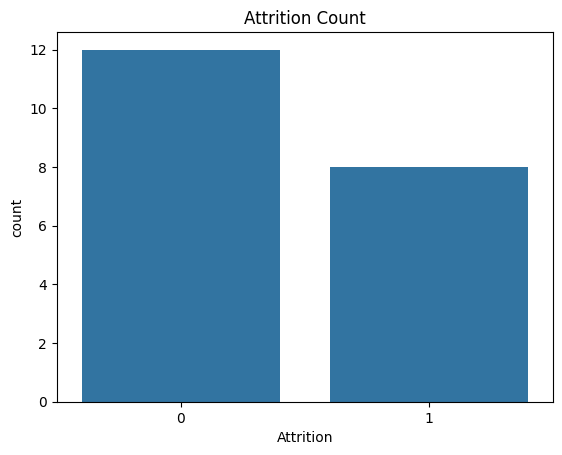

In [34]:
sns.countplot(x="Attrition", data=df)

plt.title("Attrition Count")

plt.savefig("attrition_count.png")

plt.show()

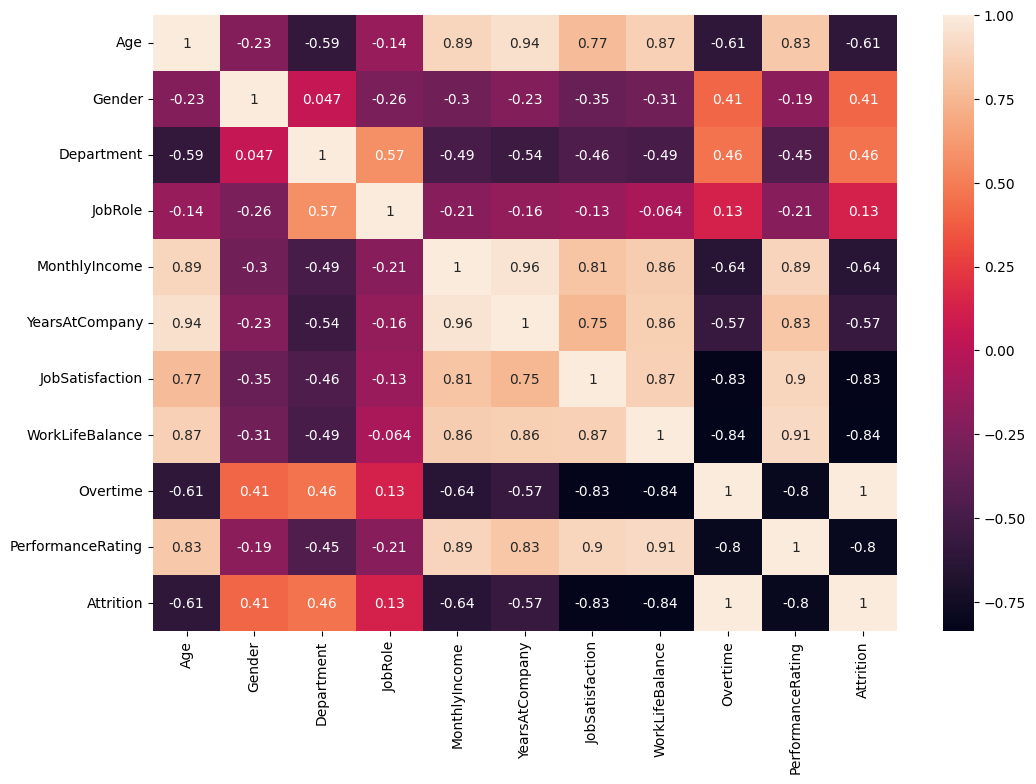

In [35]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True)

plt.savefig("heatmap.png")

plt.show()

In [36]:
plt.savefig("feature_importance.png")

<Figure size 640x480 with 0 Axes>

In [37]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [38]:
import os

print(os.listdir())

['.config', 'feature_importance.png', 'employee_attrition_model.pkl', 'heatmap.png', 'attrition_count.png', 'confusion_matrix.png', 'employee_attrition.csv', 'sample_data']
